In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [3]:
df = pd.read_csv("/kaggle/input/datasets/abhi4201/safesurf-dataset/SafeSurf Dataset Layer 1.csv")

df.head()

,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:31,118045988,177,175,48365,...,0,22590692.25,20961845.56,50206758,417585,6.708557e+06,9.217358e+05,7774731,5550108,Darknet
1,192.168.200.136,57621,192.168.200.255,57621,17,3/3/2025 20:31,90026370,3,1,132,...,0,0.00,0.00,0,0,3.000879e+07,1.250739e+04,30023227,30001233,Darknet
2,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:33,111011533,7964,3228,10145344,...,0,23004743.00,15648124.03,39628371,8560635,8.078238e+06,2.523863e+06,10710281,5678637,Darknet
3,192.168.200.136,57621,192.168.200.255,57621,17,3/3/2025 20:33,99838718,5,1,220,...,0,3029139.00,0.00,3029139,3029139,2.420239e+07,1.164261e+07,30039552,6738482,Darknet
4,192.168.200.136,5353,224.0.0.251,5353,17,3/3/2025 20:32,119999236,1,1,45,...,0,0.00,0.00,0,0,1.199992e+08,0.000000e+00,119999236,119999236,Darknet


In [4]:
!wget https://check.torproject.org/exit-addresses

--2026-03-13 16:39:24--  https://check.torproject.org/exit-addresses
Resolving check.torproject.org (check.torproject.org)... 116.202.120.181
Connecting to check.torproject.org (check.torproject.org)|116.202.120.181|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 446074 (436K)
Saving to: ‘exit-addresses’

exit-addresses      100%[===================>] 435.62K  --.-KB/s    in 0.07s   

2026-03-13 16:39:24 (5.85 MB/s) - ‘exit-addresses’ saved [446074/446074]



In [5]:
!ls exit-addresses

exit-addresses


In [6]:
tor_ips = []

with open("/kaggle/working/exit-addresses") as f:
    for line in f:
        if "ExitAddress" in line:
            tor_ips.append(line.split()[1])

In [7]:
print(len(tor_ips))

2838


In [8]:
df["tor_flag"] = df["Dst IP"].isin(tor_ips)

In [9]:
df[df["tor_flag"]==True].head()

,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,tor_flag
3201,192.168.1.70,13741,185.246.84.179,14508,17,2/10/2025 12:14,4341041,14,12,7087,...,0.0,0.0,0,0,0.000,0.000,0,0,Darknet,True
3236,192.168.1.70,13741,185.246.84.179,14508,17,2/10/2025 12:14,48265384,165,306,54972,...,0.0,0.0,0,0,0.000,0.000,0,0,Darknet,True
3298,192.168.1.70,13741,185.246.84.179,14508,17,2/10/2025 11:43,20593074,68,93,20907,...,0.0,0.0,0,0,0.000,0.000,0,0,Darknet,True
3397,192.168.1.70,13741,185.246.84.179,14508,17,2/10/2025 11:43,37576850,99,65,108457,...,0.0,0.0,0,0,1892593.333,1463905.281,3932734,567732,Darknet,True
3478,192.168.1.70,13741,185.246.84.179,14508,17,2/10/2025 11:45,32194696,86,64,48245,...,0.0,0.0,0,0,1046914.500,472369.500,1519284,574545,Darknet,True


In [10]:
tor_ports = [9001,9030,9050,9150]

df["tor_port_flag"] = df["Dst Port"].isin(tor_ports)

In [11]:
features = df[[
"Flow Duration",
"Tot Fwd Pkts",
"Tot Bwd Pkts",
"TotLen Fwd Pkts",
"TotLen Bwd Pkts"
]]

In [12]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    contamination=0.02,
    random_state=42
)

df["anomaly"] = model.fit_predict(features)

In [13]:
suspicious = df[
(df["tor_flag"]==True) |
(df["tor_port_flag"]==True) |
(df["anomaly"]==-1)
]

suspicious.head(10)

,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,...,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,tor_flag,tor_port_flag,anomaly
2,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:33,111011533,7964,3228,10145344,...,39628371,8560635,8078237.667,2523862.621,10710281,5678637,Darknet,False,False,-1
7,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:38,119692965,700,586,408568,...,32343887,4060178,7319981.250,1197165.103,8881546,5978411,Darknet,False,False,-1
10,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:40,117748522,9201,5806,10299965,...,0,0,0.000,0.000,0,0,Darknet,False,False,-1
14,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:42,119976192,1469,1380,746265,...,26420504,26420504,5870065.000,0.000,5870065,5870065,Darknet,False,False,-1
16,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:44,119932052,2047,1857,1283887,...,0,0,0.000,0.000,0,0,Darknet,False,False,-1
21,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:46,119916730,2211,1896,1222774,...,0,0,0.000,0.000,0,0,Darknet,False,False,-1
25,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:48,119976481,8427,4276,10286210,...,0,0,0.000,0.000,0,0,Darknet,False,False,-1
29,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:50,119438664,4757,2285,5229594,...,84881733,84881733,7069969.000,0.000,7069969,7069969,Darknet,False,False,-1
35,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:54,119999412,4806,1594,6174707,...,24332195,292354,7891062.833,1586748.839,10307144,5667385,Darknet,False,False,-1
40,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:58,119967264,1317,732,1230478,...,35626735,1700851,8593435.800,2568470.170,11985848,5559701,Darknet,False,False,-1


In [14]:
df[["Src IP","Dst IP","Dst Port","tor_flag","tor_port_flag","anomaly"]].head(20)

,Src IP,Dst IP,Dst Port,tor_flag,tor_port_flag,anomaly
0,13.83.126.253,192.168.200.136,42796,False,False,1
1,192.168.200.136,192.168.200.255,57621,False,False,1
2,13.83.126.253,192.168.200.136,42796,False,False,-1
3,192.168.200.136,192.168.200.255,57621,False,False,1
4,192.168.200.136,224.0.0.251,5353,False,False,1
5,13.83.126.253,192.168.200.136,42796,False,False,1
6,192.168.200.136,192.168.200.255,57621,False,False,1
7,13.83.126.253,192.168.200.136,42796,False,False,-1
8,192.168.200.136,192.168.200.255,57621,False,False,1
9,192.168.200.136,239.255.255.250,1900,False,False,1


In [15]:
df["anomaly"].value_counts()

anomaly
 1    247934
-1      5060
Name: count, dtype: int64

In [16]:
suspicious = df[df["anomaly"] == -1]

suspicious[["Src IP","Dst IP","Dst Port","Flow Duration","Tot Fwd Pkts"]].head(20)

,Src IP,Dst IP,Dst Port,Flow Duration,Tot Fwd Pkts
2,13.83.126.253,192.168.200.136,42796,111011533,7964
7,13.83.126.253,192.168.200.136,42796,119692965,700
10,13.83.126.253,192.168.200.136,42796,117748522,9201
14,13.83.126.253,192.168.200.136,42796,119976192,1469
16,13.83.126.253,192.168.200.136,42796,119932052,2047
21,13.83.126.253,192.168.200.136,42796,119916730,2211
25,13.83.126.253,192.168.200.136,42796,119976481,8427
29,13.83.126.253,192.168.200.136,42796,119438664,4757
35,13.83.126.253,192.168.200.136,42796,119999412,4806
40,13.83.126.253,192.168.200.136,42796,119967264,1317


In [17]:
df["tor_behavior"] = (
(df["Flow Duration"] > df["Flow Duration"].quantile(0.95)) &
(df["Tot Fwd Pkts"] > df["Tot Fwd Pkts"].quantile(0.95))
)

In [18]:
df[df["tor_behavior"]==True].head()

,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,tor_flag,tor_port_flag,anomaly,tor_behavior
5,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:35,119045844,415,344,299895,...,400832,6061493.50,1539099.701,9019345,5000947,Darknet,False,False,1,True
7,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:38,119692965,700,586,408568,...,4060178,7319981.25,1197165.103,8881546,5978411,Darknet,False,False,-1,True
14,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:42,119976192,1469,1380,746265,...,26420504,5870065.00,0.000,5870065,5870065,Darknet,False,False,-1,True
16,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:44,119932052,2047,1857,1283887,...,0,0.00,0.000,0,0,Darknet,False,False,-1,True
21,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:46,119916730,2211,1896,1222774,...,0,0.00,0.000,0,0,Darknet,False,False,-1,True


In [19]:
suspicious = df[
(df["anomaly"]==-1) |
(df["tor_behavior"]==True)
]

suspicious.head(20)

,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,tor_flag,tor_port_flag,anomaly,tor_behavior
2,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:33,111011533,7964,3228,10145344,...,8560635,8.078238e+06,2523862.621,10710281,5678637,Darknet,False,False,-1,False
5,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:35,119045844,415,344,299895,...,400832,6.061494e+06,1539099.701,9019345,5000947,Darknet,False,False,1,True
7,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:38,119692965,700,586,408568,...,4060178,7.319981e+06,1197165.103,8881546,5978411,Darknet,False,False,-1,True
10,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:40,117748522,9201,5806,10299965,...,0,0.000000e+00,0.000,0,0,Darknet,False,False,-1,False
14,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:42,119976192,1469,1380,746265,...,26420504,5.870065e+06,0.000,5870065,5870065,Darknet,False,False,-1,True
16,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:44,119932052,2047,1857,1283887,...,0,0.000000e+00,0.000,0,0,Darknet,False,False,-1,True
21,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:46,119916730,2211,1896,1222774,...,0,0.000000e+00,0.000,0,0,Darknet,False,False,-1,True
25,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:48,119976481,8427,4276,10286210,...,0,0.000000e+00,0.000,0,0,Darknet,False,False,-1,True
29,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:50,119438664,4757,2285,5229594,...,84881733,7.069969e+06,0.000,7069969,7069969,Darknet,False,False,-1,True
33,13.83.126.253,1194,192.168.200.136,42796,17,3/3/2025 20:52,119423638,384,376,150129,...,1235738,7.898346e+06,2893276.173,12005630,5749388,Darknet,False,False,1,True


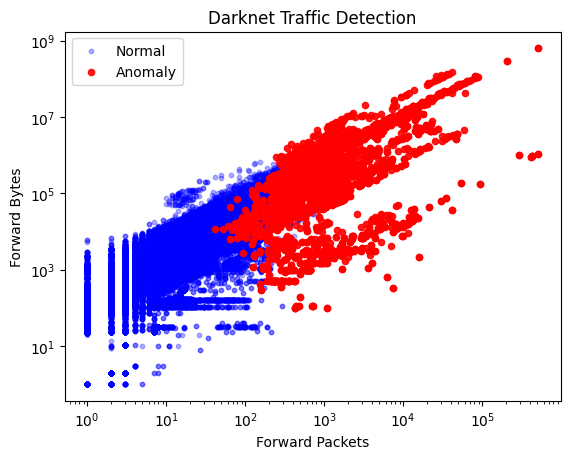

In [21]:
import matplotlib.pyplot as plt

normal = df[df["anomaly"] == 1]
anomaly = df[df["anomaly"] == -1]

# 1. Use distinct colors (e.g., blue for normal, red for anomaly)
plt.scatter(normal["Tot Fwd Pkts"], normal["TotLen Fwd Pkts"], 
            color='blue', label='Normal', alpha=0.3, s=10)
plt.scatter(anomaly["Tot Fwd Pkts"], anomaly["TotLen Fwd Pkts"], 
            color='red', label='Anomaly', alpha=0.9, s=20)

plt.xlabel("Forward Packets")
plt.ylabel("Forward Bytes")
plt.title("Darknet Traffic Detection")

plt.legend()

# ADD THESE TWO LINES:
plt.xscale('log')
plt.yscale('log')

plt.show()

# Network traffic graph Visualization

In [47]:
import networkx as nx
import matplotlib.pyplot as plt

In [48]:
suspicious = df[df["anomaly"] == -1]

suspicious = suspicious[["Src IP","Dst IP"]]

In [49]:
G = nx.from_pandas_edgelist(
    suspicious,
    source="Src IP",
    target="Dst IP"
)

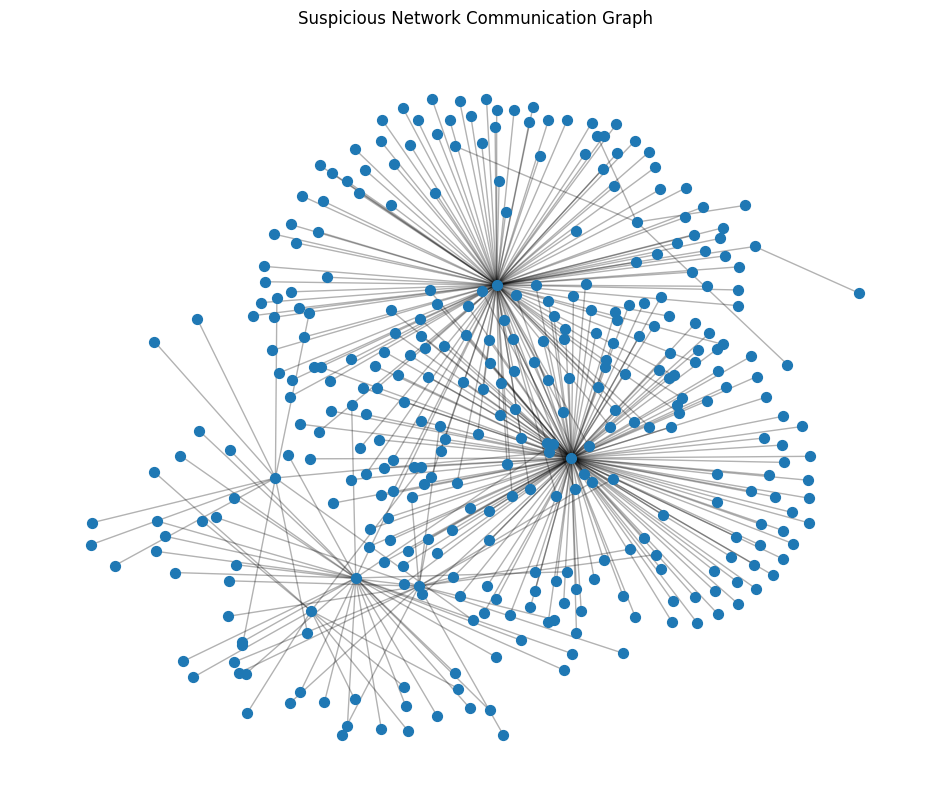

In [50]:
plt.figure(figsize=(12,10))

pos = nx.spring_layout(G, k=0.3)

nx.draw_networkx_nodes(G, pos, node_size=50)

nx.draw_networkx_edges(G, pos, alpha=0.3)

plt.title("Suspicious Network Communication Graph")

plt.axis("off")

plt.show()

In [51]:
tor_nodes = df[df["tor_flag"]==True]["Dst IP"]

node_colors = []

for node in G.nodes():
    if node in tor_nodes.values:
        node_colors.append("red")
    else:
        node_colors.append("blue")

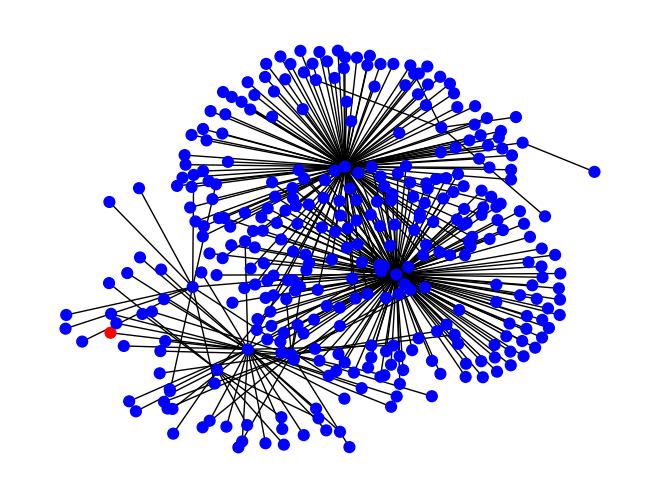

In [52]:
nx.draw(G, pos, node_color=node_colors, node_size=60)

In [53]:
tor_stats = df[df["tor_flag"]==True]

tor_stats["Dst IP"].value_counts().head(10)

Dst IP
185.246.84.179     56
185.220.101.129    52
185.220.101.3      36
205.185.113.180    21
185.220.101.21     20
185.220.101.145    16
185.220.101.178    12
185.220.101.42      4
23.129.64.211       4
185.220.101.144     4
Name: count, dtype: int64

Text(0.5, 1.0, 'Most Contacted Tor Exit Nodes')

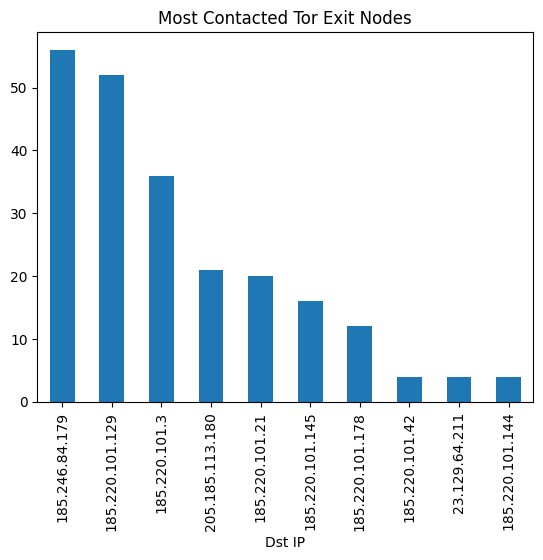

In [54]:
tor_stats["Dst IP"].value_counts().head(10).plot(kind="bar")
plt.title("Most Contacted Tor Exit Nodes")

In [55]:
df["Protocol"].value_counts()

Protocol
17    171772
6      76975
0       4247
Name: count, dtype: int64

Text(0.5, 1.0, 'Protocol Distribution')

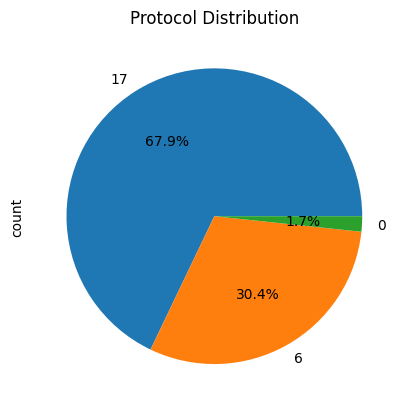

In [56]:
df["Protocol"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Protocol Distribution")